# UAS KDWM - KLASIFIKASI STROKE PREDICTION DATASET

**Tema:** Klasifikasi  
**Dataset:** Stroke Prediction Dataset  
**File CSV yang digunakan:** `healthcare-dataset-stroke-data.csv`  

**Nama : Fahri Ilham Muzzaki**

**NIM : 1224160057**

**Kelas : SIM 24 SI**

Notebook ini dibuat dengan alur seperti:  
1. Business Understanding  
2. Data Understanding  
3. Data Preparation  
4. Modeling  
5. Evaluation  
6. Kesimpulan

In [1]:
# ============================================================
# IMPORT LIBRARY
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report

plt.rcParams['figure.figsize'] = (12, 5)
sns.set_style('whitegrid')

print('Library berhasil di-import')

Library berhasil di-import


In [2]:
# ============================================================
# FASE 1 - BUSINESS UNDERSTANDING
# ============================================================

print('=' * 70)
print('FASE 1: BUSINESS UNDERSTANDING')
print('=' * 70)

print('''
Latar Belakang:
Stroke merupakan salah satu gangguan kesehatan serius yang dapat dipengaruhi
oleh faktor demografis dan kondisi kesehatan, seperti usia, hipertensi,
penyakit jantung, kadar glukosa, indeks massa tubuh, dan kebiasaan merokok.

Permasalahan:
Bagaimana membangun model klasifikasi untuk memprediksi apakah seseorang
berpotensi mengalami stroke berdasarkan data kesehatan pasien?

Tujuan:
1. Memahami karakteristik data pasien pada Stroke Prediction Dataset.
2. Melakukan data preparation agar dataset siap digunakan untuk machine learning.
3. Membuat model klasifikasi untuk memprediksi variabel target stroke.
4. Mengevaluasi performa model menggunakan confusion matrix, accuracy,
   precision, recall, dan f1-score.

Manfaat:
Hasil analisis dapat digunakan sebagai simulasi sistem pendukung analisis awal
untuk mengenali faktor risiko stroke. Model ini bukan alat diagnosis medis.
''')

FASE 1: BUSINESS UNDERSTANDING

Latar Belakang:
Stroke merupakan salah satu gangguan kesehatan serius yang dapat dipengaruhi
oleh faktor demografis dan kondisi kesehatan, seperti usia, hipertensi,
penyakit jantung, kadar glukosa, indeks massa tubuh, dan kebiasaan merokok.

Permasalahan:
Bagaimana membangun model klasifikasi untuk memprediksi apakah seseorang
berpotensi mengalami stroke berdasarkan data kesehatan pasien?

Tujuan:
1. Memahami karakteristik data pasien pada Stroke Prediction Dataset.
2. Melakukan data preparation agar dataset siap digunakan untuk machine learning.
3. Membuat model klasifikasi untuk memprediksi variabel target stroke.
4. Mengevaluasi performa model menggunakan confusion matrix, accuracy,
   precision, recall, dan f1-score.

Manfaat:
Hasil analisis dapat digunakan sebagai simulasi sistem pendukung analisis awal
untuk mengenali faktor risiko stroke. Model ini bukan alat diagnosis medis.



In [3]:
# ============================================================
# LOAD DATASET
# ============================================================


import os

file_csv = 'healthcare-dataset-stroke-data.csv'

if os.path.exists(file_csv):
    df = pd.read_csv(file_csv)
    print('Dataset berhasil dimuat')
    print(f'Nama file      : {file_csv}')
    print(f'Ukuran dataset: {df.shape[0]} baris dan {df.shape[1]} kolom')
else:
    print('File CSV tidak ditemukan.')
    print('Daftar file CSV yang ada di folder ini:')
    print([file for file in os.listdir() if file.endswith('.csv')])
    print('\nJika nama CSV berbeda, ganti nilai variabel file_csv dengan nama file tersebut.')


Dataset berhasil dimuat
Nama file      : healthcare-dataset-stroke-data.csv
Ukuran dataset: 5110 baris dan 12 kolom


In [4]:
# Menampilkan 5 data pertama
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [5]:
# ============================================================
# FASE 2 - DATA UNDERSTANDING
# ============================================================

print('=' * 70)
print('FASE 2: DATA UNDERSTANDING')
print('=' * 70)

print('\n1. Ukuran Dataset')
print(f'Jumlah baris  : {df.shape[0]}')
print(f'Jumlah kolom  : {df.shape[1]}')

print('\n2. Nama Kolom')
print(df.columns.tolist())

print('\n3. Informasi Dataset')
df.info()


FASE 2: DATA UNDERSTANDING

1. Ukuran Dataset
Jumlah baris  : 5110
Jumlah kolom  : 12

2. Nama Kolom
['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'avg_glucose_level', 'bmi', 'smoking_status', 'stroke']

3. Informasi Dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-n

In [6]:
# Statistik deskriptif untuk kolom numerik
print('=' * 70)
print('STATISTIK DESKRIPTIF DATA NUMERIK')
print('=' * 70)
df.describe()

STATISTIK DESKRIPTIF DATA NUMERIK


,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


In [7]:
# Cek missing value, duplikat, dan nilai unik
print('=' * 70)
print('IDENTIFIKASI KUALITAS DATA')
print('=' * 70)

print('\n1. Missing Value per Kolom:')
print(df.isnull().sum())

print(f'\n2. Jumlah Data Duplikat: {df.duplicated().sum()} baris')

print('\n3. Jumlah Nilai Unik per Kolom:')
print(df.nunique())


IDENTIFIKASI KUALITAS DATA

1. Missing Value per Kolom:
id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

2. Jumlah Data Duplikat: 0 baris

3. Jumlah Nilai Unik per Kolom:
id                   5110
gender                  3
age                   104
hypertension            2
heart_disease           2
ever_married            2
work_type               5
Residence_type          2
avg_glucose_level    3979
bmi                   418
smoking_status          4
stroke                  2
dtype: int64


DISTRIBUSI TARGET KLASIFIKASI
stroke
0    4861
1     249
Name: count, dtype: int64

Persentase Target:
stroke
0    95.127202
1     4.872798
Name: proportion, dtype: float64


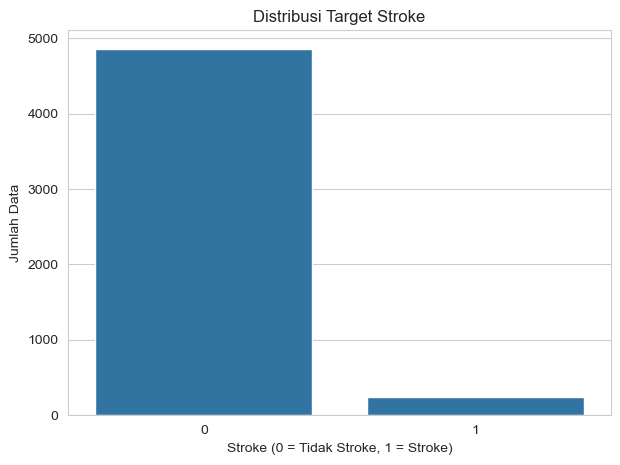

In [8]:
# Distribusi target stroke
print('=' * 70)
print('DISTRIBUSI TARGET KLASIFIKASI')
print('=' * 70)

print(df['stroke'].value_counts())
print('\nPersentase Target:')
print(df['stroke'].value_counts(normalize=True) * 100)

plt.figure(figsize=(7, 5))
sns.countplot(x='stroke', data=df)
plt.title('Distribusi Target Stroke')
plt.xlabel('Stroke (0 = Tidak Stroke, 1 = Stroke)')
plt.ylabel('Jumlah Data')
plt.show()


EXPLORATORY DATA ANALYSIS


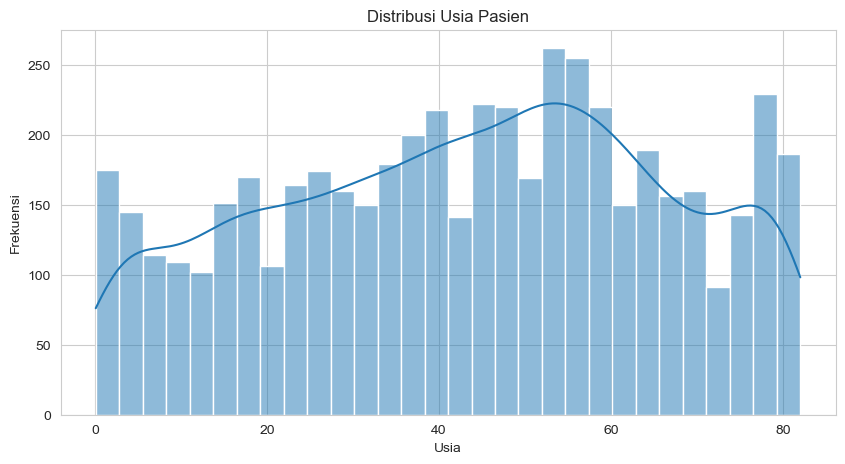

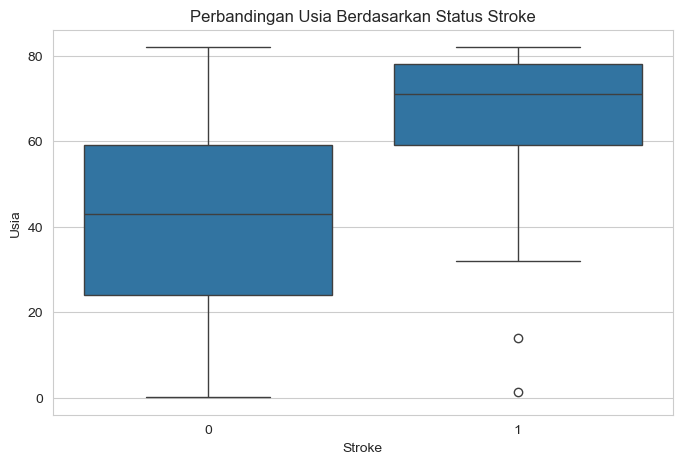

In [9]:
# ============================================================
# EDA - EXPLORATORY DATA ANALYSIS
# ============================================================

print('=' * 70)
print('EXPLORATORY DATA ANALYSIS')
print('=' * 70)

# Distribusi usia
plt.figure(figsize=(10,5))
sns.histplot(df['age'], kde=True, bins=30)
plt.title('Distribusi Usia Pasien')
plt.xlabel('Usia')
plt.ylabel('Frekuensi')
plt.show()

# Hubungan usia dengan stroke
plt.figure(figsize=(8,5))
sns.boxplot(x='stroke', y='age', data=df)
plt.title('Perbandingan Usia Berdasarkan Status Stroke')
plt.xlabel('Stroke')
plt.ylabel('Usia')
plt.show()

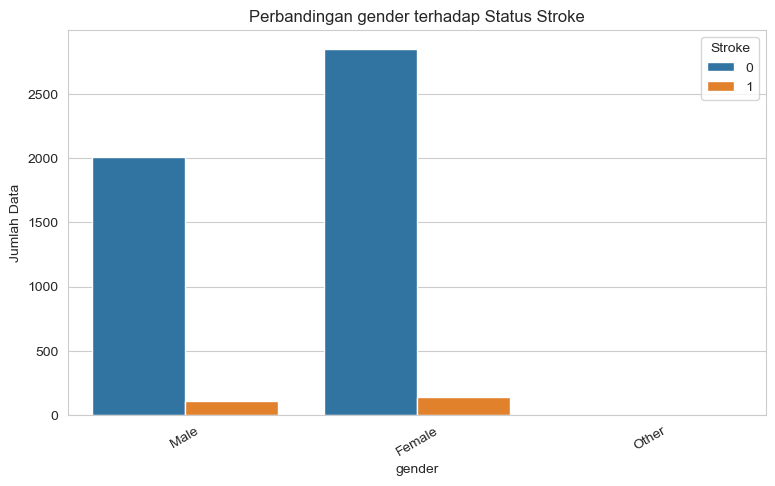

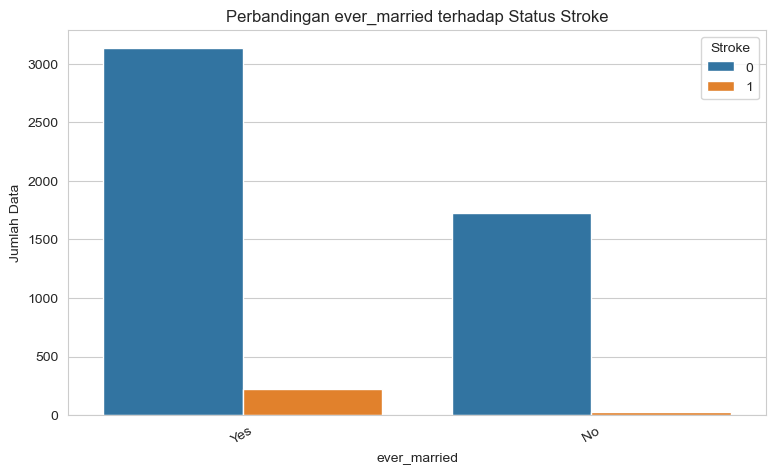

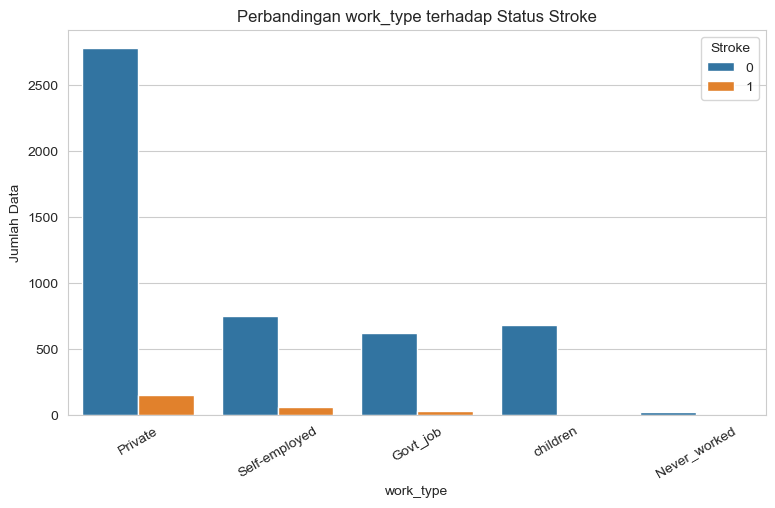

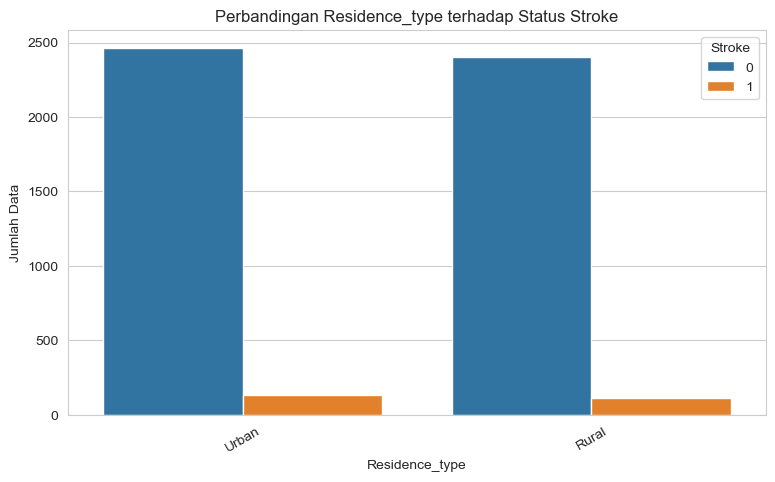

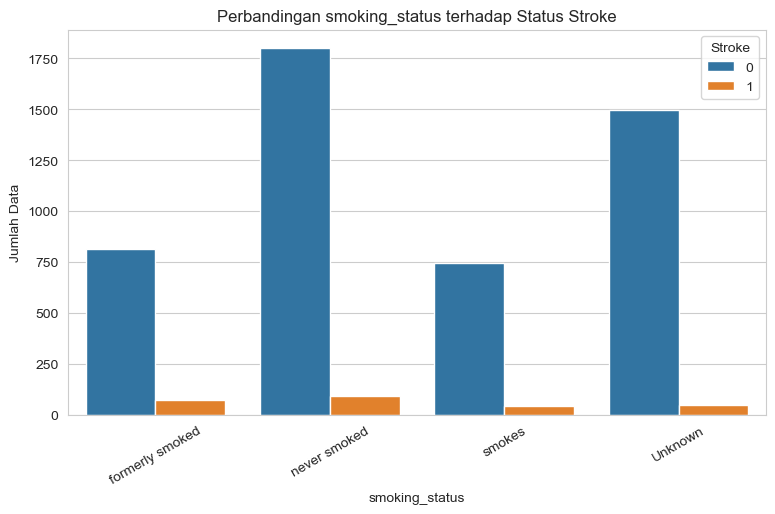

In [10]:
# Visualisasi beberapa fitur kategorikal terhadap target
categorical_cols = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']

for col in categorical_cols:
    plt.figure(figsize=(9,5))
    sns.countplot(x=col, hue='stroke', data=df)
    plt.title(f'Perbandingan {col} terhadap Status Stroke')
    plt.xlabel(col)
    plt.ylabel('Jumlah Data')
    plt.xticks(rotation=30)
    plt.legend(title='Stroke')
    plt.show()

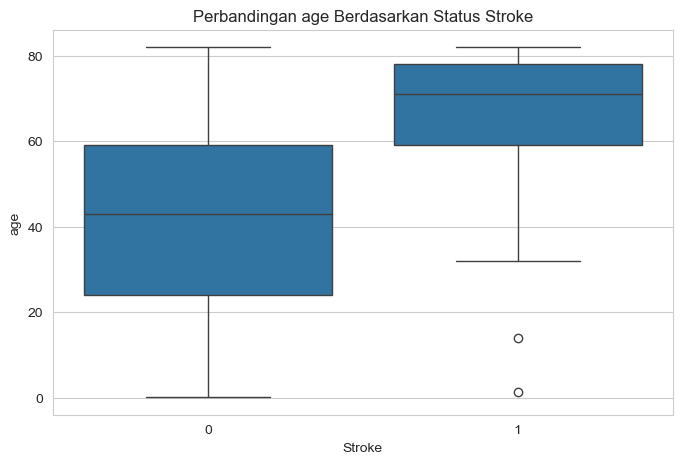

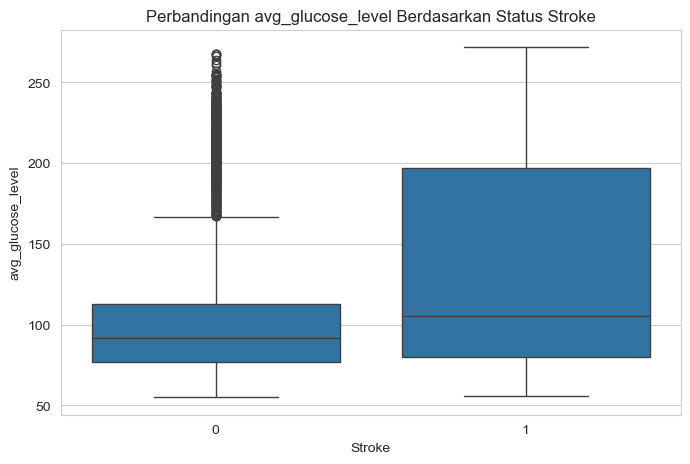

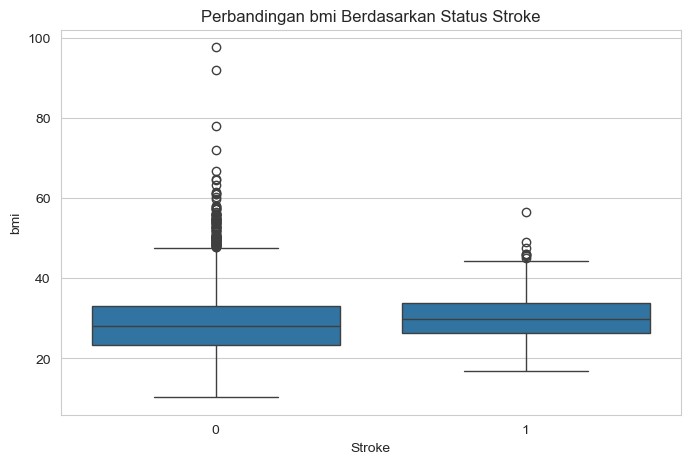

In [11]:
# Visualisasi fitur numerik terhadap target
numeric_cols = ['age', 'avg_glucose_level', 'bmi']

for col in numeric_cols:
    plt.figure(figsize=(8,5))
    sns.boxplot(x='stroke', y=col, data=df)
    plt.title(f'Perbandingan {col} Berdasarkan Status Stroke')
    plt.xlabel('Stroke')
    plt.ylabel(col)
    plt.show()

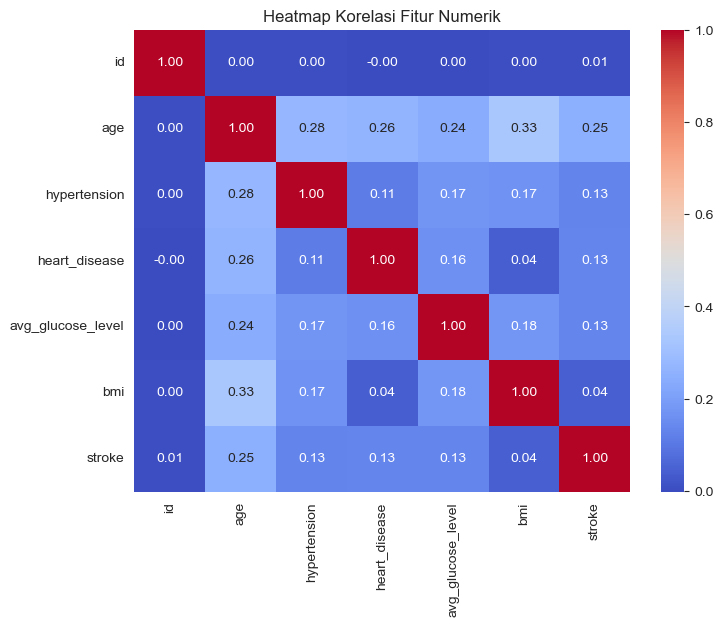

In [12]:
# Korelasi fitur numerik
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Heatmap Korelasi Fitur Numerik')
plt.show()

In [13]:
# ============================================================
# FASE 3 - DATA PREPARATION
# ============================================================

print('=' * 70)
print('FASE 3: DATA PREPARATION')
print('=' * 70)

# Membuat salinan data agar data asli tetap aman
df_clean = df.copy()

print('Data berhasil disalin ke df_clean')

FASE 3: DATA PREPARATION
Data berhasil disalin ke df_clean


In [14]:
# Step 1: Menghapus kolom id karena hanya berfungsi sebagai identitas dan bukan fitur prediksi
if 'id' in df_clean.columns:
    df_clean = df_clean.drop('id', axis=1)
    print('Kolom id berhasil dihapus')
else:
    print('Kolom id tidak ditemukan')

print('Kolom setelah penghapusan id:')
print(df_clean.columns.tolist())

Kolom id berhasil dihapus
Kolom setelah penghapusan id:
['gender', 'age', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'avg_glucose_level', 'bmi', 'smoking_status', 'stroke']


In [15]:
# Step 2: Menangani missing value pada kolom bmi
print('Missing value sebelum ditangani:')
print(df_clean.isnull().sum())

median_bmi = df_clean['bmi'].median()
df_clean['bmi'] = df_clean['bmi'].fillna(median_bmi)

print('\nMissing value setelah ditangani:')
print(df_clean.isnull().sum())
print(f'\nNilai kosong pada bmi diisi dengan median: {median_bmi}')


Missing value sebelum ditangani:
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

Missing value setelah ditangani:
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64

Nilai kosong pada bmi diisi dengan median: 28.1


In [16]:
# Step 3: Membersihkan nilai kategori yang jarang/tidak diperlukan
print('Nilai unik gender sebelum cleaning:')
print(df_clean['gender'].value_counts())

# Jika ada kategori 'Other', data tersebut dihapus karena jumlahnya sangat sedikit
df_clean = df_clean[df_clean['gender'] != 'Other'].copy()

print('\nNilai unik gender setelah cleaning:')
print(df_clean['gender'].value_counts())


Nilai unik gender sebelum cleaning:
gender
Female    2994
Male      2115
Other        1
Name: count, dtype: int64

Nilai unik gender setelah cleaning:
gender
Female    2994
Male      2115
Name: count, dtype: int64


In [17]:
# Step 4: Encoding data kategorikal menggunakan One-Hot Encoding
cat_cols = df_clean.select_dtypes(include='object').columns.tolist()
print('Kolom kategorikal yang akan di-encoding:')
print(cat_cols)

df_encoded = pd.get_dummies(df_clean, columns=cat_cols, drop_first=True)

print('\nUkuran data setelah encoding:')
print(df_encoded.shape)

df_encoded.head()


Kolom kategorikal yang akan di-encoding:
['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']

Ukuran data setelah encoding:
(5109, 16)


,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke,gender_Male,ever_married_Yes,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Urban,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,67.0,0,1,228.69,36.6,1,True,True,False,True,False,False,True,True,False,False
1,61.0,0,0,202.21,28.1,1,False,True,False,False,True,False,False,False,True,False
2,80.0,0,1,105.92,32.5,1,True,True,False,True,False,False,False,False,True,False
3,49.0,0,0,171.23,34.4,1,False,True,False,True,False,False,True,False,False,True
4,79.0,1,0,174.12,24.0,1,False,True,False,False,True,False,False,False,True,False


In [18]:
# Step 5: Memisahkan fitur X dan target y
X = df_encoded.drop('stroke', axis=1)
y = df_encoded['stroke']

print('Jumlah fitur:', X.shape[1])
print('Jumlah data :', X.shape[0])
print('\nDistribusi target:')
print(y.value_counts())


Jumlah fitur: 15
Jumlah data : 5109

Distribusi target:
stroke
0    4860
1     249
Name: count, dtype: int64


In [19]:
# Step 6: Membagi data menjadi data training dan data testing
# stratify=y digunakan agar proporsi target 0 dan 1 tetap seimbang di train-test

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('Ukuran X_train:', X_train.shape)
print('Ukuran X_test :', X_test.shape)
print('Ukuran y_train:', y_train.shape)
print('Ukuran y_test :', y_test.shape)

Ukuran X_train: (4087, 15)
Ukuran X_test : (1022, 15)
Ukuran y_train: (4087,)
Ukuran y_test : (1022,)


In [20]:
# Step 7: Scaling fitur numerik
# Scaling penting terutama untuk Logistic Regression dan KNN

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Scaling selesai dilakukan')

Scaling selesai dilakukan


In [21]:
# ============================================================
# FASE 4 - MODELING
# ============================================================

print('=' * 70)
print('FASE 4: MODELING')
print('=' * 70)

# Membuat beberapa model klasifikasi sebagai pembanding
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5)
}

print('Model yang digunakan:')
for name in models.keys():
    print('-', name)

FASE 4: MODELING
Model yang digunakan:
- Logistic Regression
- Decision Tree
- Random Forest
- K-Nearest Neighbors


In [22]:
# Melatih model dan menyimpan hasil prediksi
results = []
predictions = {}

for name, model in models.items():
    print('=' * 70)
    print(f'Training model: {name}')
    print('=' * 70)
    
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    predictions[name] = y_pred
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    
    results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1
    })
    
    print(f'Accuracy  : {acc:.4f}')
    print(f'Precision : {prec:.4f}')
    print(f'Recall    : {rec:.4f}')
    print(f'F1-Score  : {f1:.4f}')

Training model: Logistic Regression
Accuracy  : 0.7387
Precision : 0.1347
Recall    : 0.8000
F1-Score  : 0.2305
Training model: Decision Tree
Accuracy  : 0.9217
Precision : 0.2000
Recall    : 0.2000
F1-Score  : 0.2000
Training model: Random Forest
Accuracy  : 0.9501
Precision : 0.0000
Recall    : 0.0000
F1-Score  : 0.0000
Training model: K-Nearest Neighbors
Accuracy  : 0.9491
Precision : 0.2500
Recall    : 0.0200
F1-Score  : 0.0370


In [23]:
# ============================================================
# FASE 5 - EVALUATION
# ============================================================

print('=' * 70)
print('FASE 5: EVALUATION')
print('=' * 70)

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by='F1-Score', ascending=False).reset_index(drop=True)

print('Perbandingan performa model:')
results_df


FASE 5: EVALUATION
Perbandingan performa model:


,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.738748,0.13468,0.80,0.230548
1,Decision Tree,0.921722,0.20000,0.20,0.200000
2,K-Nearest Neighbors,0.949119,0.25000,0.02,0.037037
3,Random Forest,0.950098,0.00000,0.00,0.000000


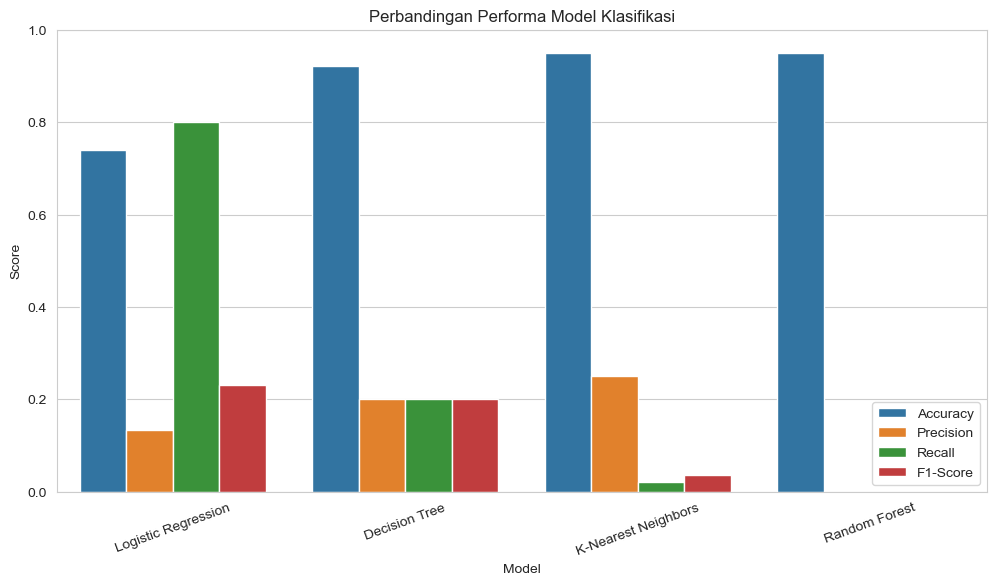

In [24]:
# Visualisasi perbandingan performa model
results_melt = results_df.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(12,6))
sns.barplot(x='Model', y='Score', hue='Metric', data=results_melt)
plt.title('Perbandingan Performa Model Klasifikasi')
plt.xlabel('Model')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.legend(loc='lower right')
plt.show()

In [25]:
# Menentukan model terbaik berdasarkan F1-Score
best_model_name = results_df.iloc[0]['Model']
best_y_pred = predictions[best_model_name]

print('=' * 70)
print('MODEL TERBAIK BERDASARKAN F1-SCORE')
print('=' * 70)
print(f'Model terbaik: {best_model_name}')
print('\nClassification Report:')
print(classification_report(y_test, best_y_pred, zero_division=0))


MODEL TERBAIK BERDASARKAN F1-SCORE
Model terbaik: Logistic Regression

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.74      0.84       972
           1       0.13      0.80      0.23        50

    accuracy                           0.74      1022
   macro avg       0.56      0.77      0.54      1022
weighted avg       0.94      0.74      0.81      1022



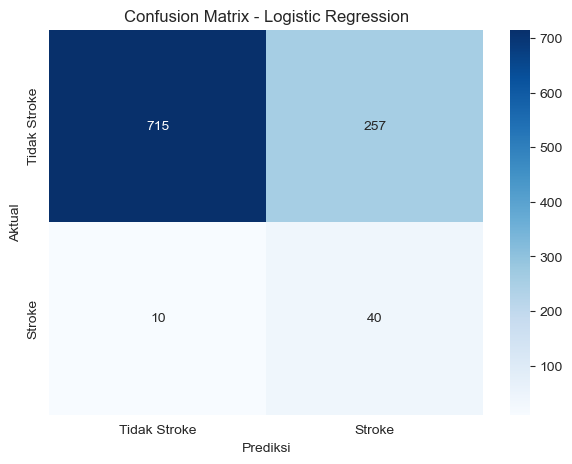

Confusion Matrix:
[[715 257]
 [ 10  40]]


In [26]:
# Confusion Matrix model terbaik
cm = confusion_matrix(y_test, best_y_pred)

plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Tidak Stroke', 'Stroke'],
            yticklabels=['Tidak Stroke', 'Stroke'])
plt.title(f'Confusion Matrix - {best_model_name}')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.show()

print('Confusion Matrix:')
print(cm)

In [27]:
# Menampilkan classification report untuk semua model
for name, y_pred in predictions.items():
    print('=' * 70)
    print(f'CLASSIFICATION REPORT: {name}')
    print('=' * 70)
    print(classification_report(y_test, y_pred, zero_division=0))

CLASSIFICATION REPORT: Logistic Regression
              precision    recall  f1-score   support

           0       0.99      0.74      0.84       972
           1       0.13      0.80      0.23        50

    accuracy                           0.74      1022
   macro avg       0.56      0.77      0.54      1022
weighted avg       0.94      0.74      0.81      1022

CLASSIFICATION REPORT: Decision Tree
              precision    recall  f1-score   support

           0       0.96      0.96      0.96       972
           1       0.20      0.20      0.20        50

    accuracy                           0.92      1022
   macro avg       0.58      0.58      0.58      1022
weighted avg       0.92      0.92      0.92      1022

CLASSIFICATION REPORT: Random Forest
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       972
           1       0.00      0.00      0.00        50

    accuracy                           0.95      1022
   macro av

In [28]:
# Feature Importance untuk Random Forest
# Bagian ini digunakan untuk melihat fitur yang paling berpengaruh dalam prediksi

rf_model = models['Random Forest']

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print('10 Fitur dengan pengaruh terbesar menurut Random Forest:')
feature_importance.head(10)

10 Fitur dengan pengaruh terbesar menurut Random Forest:


,Feature,Importance
0,age,0.384565
3,avg_glucose_level,0.190104
4,bmi,0.181496
1,hypertension,0.035755
6,ever_married_Yes,0.033914
5,gender_Male,0.024346
11,Residence_type_Urban,0.023280
13,smoking_status_never smoked,0.020054
2,heart_disease,0.019597
9,work_type_Self-employed,0.018401


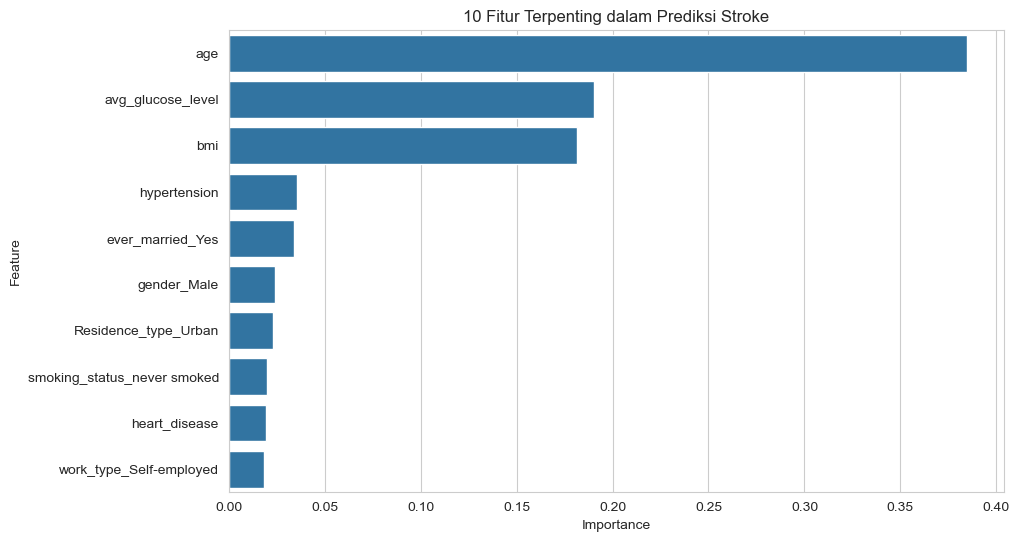

In [29]:
# Visualisasi 10 fitur terpenting
plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=feature_importance.head(10))
plt.title('10 Fitur Terpenting dalam Prediksi Stroke')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

In [30]:
# ============================================================
# INTERPRETASI HASIL
# ============================================================

print('=' * 70)
print('INTERPRETASI HASIL')
print('=' * 70)

print(f'''
Berdasarkan hasil modeling, model terbaik pada percobaan ini adalah {best_model_name}
berdasarkan nilai F1-Score.

Pada kasus klasifikasi stroke, evaluasi tidak cukup hanya menggunakan accuracy.
Hal ini karena data stroke biasanya tidak seimbang, yaitu jumlah pasien yang tidak
mengalami stroke jauh lebih banyak dibandingkan pasien yang mengalami stroke.

Metrik yang perlu diperhatikan adalah recall untuk kelas 1 atau stroke. Recall
menunjukkan kemampuan model dalam mendeteksi pasien yang benar-benar mengalami stroke.
Jika recall kelas stroke rendah, berarti masih banyak pasien stroke yang diprediksi
sebagai tidak stroke.
''')

INTERPRETASI HASIL

Berdasarkan hasil modeling, model terbaik pada percobaan ini adalah Logistic Regression
berdasarkan nilai F1-Score.

Pada kasus klasifikasi stroke, evaluasi tidak cukup hanya menggunakan accuracy.
Hal ini karena data stroke biasanya tidak seimbang, yaitu jumlah pasien yang tidak
mengalami stroke jauh lebih banyak dibandingkan pasien yang mengalami stroke.

Metrik yang perlu diperhatikan adalah recall untuk kelas 1 atau stroke. Recall
menunjukkan kemampuan model dalam mendeteksi pasien yang benar-benar mengalami stroke.
Jika recall kelas stroke rendah, berarti masih banyak pasien stroke yang diprediksi
sebagai tidak stroke.



In [31]:
# ============================================================
# KESIMPULAN
# ============================================================

print('=' * 70)
print('KESIMPULAN')
print('=' * 70)

print('''
1. Dataset Stroke Prediction Dataset dapat digunakan untuk metode klasifikasi biner
   karena memiliki target stroke dengan dua kelas, yaitu 0 dan 1.

2. Tahap data preparation yang dilakukan meliputi penghapusan kolom id,
   penanganan missing value pada kolom bmi, pembersihan kategori gender,
   encoding data kategorikal, pembagian data train-test, dan scaling fitur.

3. Model yang digunakan pada penelitian ini adalah Logistic Regression,
   Decision Tree, Random Forest, dan K-Nearest Neighbors.

4. Evaluasi model dilakukan menggunakan accuracy, precision, recall, f1-score,
   classification report, dan confusion matrix.

5. Karena distribusi target stroke tidak seimbang, maka model tidak boleh dinilai
   hanya berdasarkan accuracy. Recall dan F1-Score lebih penting untuk diperhatikan,
   terutama pada kelas stroke.

6. Hasil analisis ini bersifat pembelajaran data mining dan tidak dapat digunakan
   sebagai diagnosis medis. Model hanya berfungsi sebagai simulasi prediksi awal
   berdasarkan data historis.
''')

KESIMPULAN

1. Dataset Stroke Prediction Dataset dapat digunakan untuk metode klasifikasi biner
   karena memiliki target stroke dengan dua kelas, yaitu 0 dan 1.

2. Tahap data preparation yang dilakukan meliputi penghapusan kolom id,
   penanganan missing value pada kolom bmi, pembersihan kategori gender,
   encoding data kategorikal, pembagian data train-test, dan scaling fitur.

3. Model yang digunakan pada penelitian ini adalah Logistic Regression,
   Decision Tree, Random Forest, dan K-Nearest Neighbors.

4. Evaluasi model dilakukan menggunakan accuracy, precision, recall, f1-score,
   classification report, dan confusion matrix.

5. Karena distribusi target stroke tidak seimbang, maka model tidak boleh dinilai
   hanya berdasarkan accuracy. Recall dan F1-Score lebih penting untuk diperhatikan,
   terutama pada kelas stroke.

6. Hasil analisis ini bersifat pembelajaran data mining dan tidak dapat digunakan
   sebagai diagnosis medis. Model hanya berfungsi sebagai simulasi prediksi

In [32]:
# ============================================================
# EXPORT GAMBAR UNTUK GOOGLE SITES
# ============================================================

import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from io import StringIO
from PIL import Image, ImageDraw, ImageFont
from sklearn.metrics import confusion_matrix, classification_report

# Membuat folder penyimpanan gambar
folder_output = "gambar_sites"
os.makedirs(folder_output, exist_ok=True)

print("=" * 70)
print("EXPORT GAMBAR UNTUK GOOGLE SITES")
print("=" * 70)


# ============================================================
# 1. DATA AWAL DATASET - df.head()
# ============================================================

fig, ax = plt.subplots(figsize=(14, 4))
ax.axis("off")

table = ax.table(
    cellText=df.head().values,
    colLabels=df.head().columns,
    loc="center",
    cellLoc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1, 1.5)

plt.title("Tampilan Awal Dataset Stroke Prediction", fontsize=14, pad=20)
plt.savefig(f"{folder_output}/01_tampilan_awal_dataset.png", bbox_inches="tight", dpi=300)
plt.close()

print("Berhasil menyimpan: 01_tampilan_awal_dataset.png")


# ============================================================
# 2. INFORMASI DATASET - df.info()
# ============================================================

buffer = StringIO()
df.info(buf=buffer)
info_text = buffer.getvalue()

lines = info_text.split("\n")
font = ImageFont.load_default()

width = 1100
height = max(500, len(lines) * 18 + 50)

img = Image.new("RGB", (width, height), color="white")
draw = ImageDraw.Draw(img)

draw.text((20, 20), "Informasi Struktur Dataset", fill="black", font=font)

y = 50
for line in lines:
    draw.text((20, y), line, fill="black", font=font)
    y += 18

img.save(f"{folder_output}/02_informasi_dataset.png")

print("Berhasil menyimpan: 02_informasi_dataset.png")


# ============================================================
# 3. MISSING VALUE
# ============================================================

missing_df = df.isnull().sum().reset_index()
missing_df.columns = ["Kolom", "Jumlah Missing Value"]

fig, ax = plt.subplots(figsize=(8, 4))
ax.axis("off")

table = ax.table(
    cellText=missing_df.values,
    colLabels=missing_df.columns,
    loc="center",
    cellLoc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.4)

plt.title("Jumlah Missing Value Setiap Kolom", fontsize=14, pad=20)
plt.savefig(f"{folder_output}/03_missing_value.png", bbox_inches="tight", dpi=300)
plt.close()

print("Berhasil menyimpan: 03_missing_value.png")


# ============================================================
# 4. DISTRIBUSI TARGET STROKE
# ============================================================

plt.figure(figsize=(7, 5))
sns.countplot(x="stroke", data=df)
plt.title("Distribusi Target Stroke")
plt.xlabel("Stroke")
plt.ylabel("Jumlah Data")
plt.savefig(f"{folder_output}/04_distribusi_target_stroke.png", bbox_inches="tight", dpi=300)
plt.close()

print("Berhasil menyimpan: 04_distribusi_target_stroke.png")


# ============================================================
# 5. DISTRIBUSI USIA PASIEN
# ============================================================

plt.figure(figsize=(8, 5))
sns.histplot(df["age"], kde=True)
plt.title("Distribusi Usia Pasien")
plt.xlabel("Usia")
plt.ylabel("Frekuensi")
plt.savefig(f"{folder_output}/05_distribusi_usia_pasien.png", bbox_inches="tight", dpi=300)
plt.close()

print("Berhasil menyimpan: 05_distribusi_usia_pasien.png")


# ============================================================
# 6. HUBUNGAN USIA DENGAN STROKE
# ============================================================

plt.figure(figsize=(7, 5))
sns.boxplot(x="stroke", y="age", data=df)
plt.title("Hubungan Usia dengan Stroke")
plt.xlabel("Stroke")
plt.ylabel("Usia")
plt.savefig(f"{folder_output}/06_hubungan_usia_dengan_stroke.png", bbox_inches="tight", dpi=300)
plt.close()

print("Berhasil menyimpan: 06_hubungan_usia_dengan_stroke.png")


# ============================================================
# 7. HUBUNGAN GLUKOSA DENGAN STROKE
# ============================================================

plt.figure(figsize=(7, 5))
sns.boxplot(x="stroke", y="avg_glucose_level", data=df)
plt.title("Hubungan Kadar Glukosa Rata-rata dengan Stroke")
plt.xlabel("Stroke")
plt.ylabel("Avg Glucose Level")
plt.savefig(f"{folder_output}/07_hubungan_glukosa_dengan_stroke.png", bbox_inches="tight", dpi=300)
plt.close()

print("Berhasil menyimpan: 07_hubungan_glukosa_dengan_stroke.png")


# ============================================================
# 8. HEATMAP KORELASI
# ============================================================

plt.figure(figsize=(9, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Korelasi Antarvariabel Numerik")
plt.savefig(f"{folder_output}/08_heatmap_korelasi.png", bbox_inches="tight", dpi=300)
plt.close()

print("Berhasil menyimpan: 08_heatmap_korelasi.png")


# ============================================================
# 9. TABEL PERBANDINGAN MODEL
# ============================================================

fig, ax = plt.subplots(figsize=(10, 3))
ax.axis("off")

table = ax.table(
    cellText=results_df.round(4).values,
    colLabels=results_df.columns,
    loc="center",
    cellLoc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.5)

plt.title("Perbandingan Performa Model Klasifikasi", fontsize=14, pad=20)
plt.savefig(f"{folder_output}/09_perbandingan_model.png", bbox_inches="tight", dpi=300)
plt.close()

print("Berhasil menyimpan: 09_perbandingan_model.png")


# ============================================================
# 10. CONFUSION MATRIX MODEL TERBAIK
# ============================================================

cm = confusion_matrix(y_test, best_y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix Model Terbaik: {best_model_name}")
plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.savefig(f"{folder_output}/10_confusion_matrix_model_terbaik.png", bbox_inches="tight", dpi=300)
plt.close()

print("Berhasil menyimpan: 10_confusion_matrix_model_terbaik.png")


# ============================================================
# 11. CLASSIFICATION REPORT MODEL TERBAIK
# ============================================================

report = classification_report(y_test, best_y_pred, zero_division=0)

lines = report.split("\n")
font = ImageFont.load_default()

width = 800
height = max(350, len(lines) * 20 + 60)

img = Image.new("RGB", (width, height), color="white")
draw = ImageDraw.Draw(img)

draw.text((20, 20), f"Classification Report Model Terbaik: {best_model_name}", fill="black", font=font)

y = 60
for line in lines:
    draw.text((20, y), line, fill="black", font=font)
    y += 20

img.save(f"{folder_output}/11_classification_report_model_terbaik.png")

print("Berhasil menyimpan: 11_classification_report_model_terbaik.png")


# ============================================================
# 12. FEATURE IMPORTANCE
# ============================================================

if "feature_importance_df" in globals():
    plt.figure(figsize=(8, 6))
    sns.barplot(
        x="Importance",
        y="Feature",
        data=feature_importance_df.head(10)
    )
    plt.title("Fitur yang Paling Berpengaruh terhadap Prediksi Stroke")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.savefig(f"{folder_output}/12_feature_importance.png", bbox_inches="tight", dpi=300)
    plt.close()
    print("Berhasil menyimpan: 12_feature_importance.png")
else:
    print("feature_importance_df belum tersedia. Lewati export feature importance.")


print("=" * 70)
print("SELESAI")
print(f"Semua gambar tersimpan di folder: {folder_output}")
print("=" * 70)

EXPORT GAMBAR UNTUK GOOGLE SITES
Berhasil menyimpan: 01_tampilan_awal_dataset.png
Berhasil menyimpan: 02_informasi_dataset.png
Berhasil menyimpan: 03_missing_value.png
Berhasil menyimpan: 04_distribusi_target_stroke.png
Berhasil menyimpan: 05_distribusi_usia_pasien.png
Berhasil menyimpan: 06_hubungan_usia_dengan_stroke.png
Berhasil menyimpan: 07_hubungan_glukosa_dengan_stroke.png
Berhasil menyimpan: 08_heatmap_korelasi.png
Berhasil menyimpan: 09_perbandingan_model.png
Berhasil menyimpan: 10_confusion_matrix_model_terbaik.png
Berhasil menyimpan: 11_classification_report_model_terbaik.png
feature_importance_df belum tersedia. Lewati export feature importance.
SELESAI
Semua gambar tersimpan di folder: gambar_sites
